# Clustering
## _k_ Means

In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
penguins_all = pd.read_csv('penguins_af.csv')
penguins = penguins_all[['bill_length_mm', 'bill_depth_mm',
                         'flipper_length_mm', 'body_mass_g']]
LE = LabelEncoder()
penguins_all['code'] = LE.fit_transform(penguins_all['species'])
y = penguins_all['code']

X_raw = penguins.values
X = StandardScaler().fit_transform(X_raw)

features = penguins.columns
features

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

Text(0, 0.5, 'flipper_length_mm')

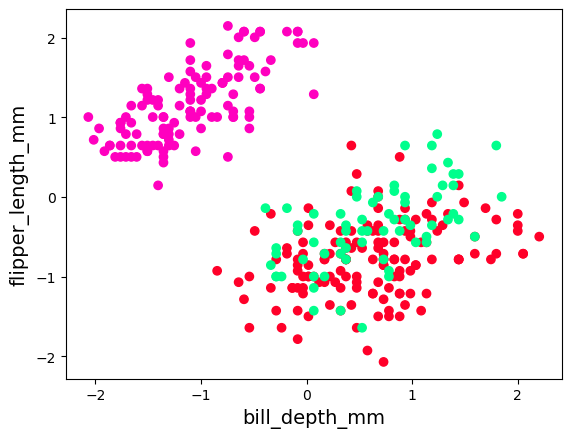

In [5]:
#choose two features from the list of features above to visualise the data
#use the index of the feature as f1 and f2
f1, f2 = 1,2
plt.scatter(X[:,f1], X[:,f2], c=y, cmap='gist_rainbow')
plt.xlabel(features[f1], fontsize=14)
plt.ylabel(features[f2], fontsize=14)

In [ ]:
#limit the data to two features so the clusters can be visualised
f1,f2 = 0,1
Xc = X[:, [f1,f2]]   

km = KMeans(n_clusters = 3, random_state=1)
km.fit(Xc)  

In [ ]:
centers = km.cluster_centers_
print(centers)

In [ ]:
#this will tell us to which cluster does the data observations belong.
new_labels = km.labels_

# Plot the identified clusters and compare with the true label
fig, axes = plt.subplots(1, 2, figsize=(14,7))
axes[0].scatter(Xc[:, 0], Xc[:, 1], c=y, cmap='gist_rainbow',
edgecolor='k', s=150)
axes[1].scatter(Xc[:, 0], Xc[:, 1], c=new_labels, 
edgecolor='k', s=150)
axes[0].set_xlabel(features[f1], fontsize=14)
axes[0].set_ylabel(features[f2], fontsize=14)
axes[1].set_xlabel(features[f1], fontsize=14)
axes[1].set_ylabel(features[f2], fontsize=14)
axes[0].tick_params(length=10, width=2, colors='k', labelsize=20)
axes[1].tick_params(length=10, width=2, colors='k', labelsize=20)
axes[0].set_title('Actual', fontsize=18)
axes[1].set_title('Clustered As', fontsize=18)

## k-Means Stability
`.inertia_` attribute is the sum of squared distances of each instance from their closest cluster centroid (intra_cluster distance).   
`n_init` parameter is the number of times the algorithm runs with different centroid seeds, (default is 10).   
`KMeans` runs  multiple times (controlled by the `n_init` parameter) and returns the clustering with the smallest interia.  
If we force `n_init = 1` we can see the different inertia values showing the different clusters obtained. 

In [ ]:
X

In [ ]:
for rs in range(5):
    km = KMeans(n_clusters = 3, n_init = 1, random_state=rs)
    km.fit(X)
    print("Intra-cluster distance: {:.3f}".format(km.inertia_))

In [ ]:
km = KMeans(n_clusters = 3, n_init = 8, random_state=1)
km.fit(X)
print("Intra-cluster distance: {:.3f}".format(km.inertia_))

## _k_ Means Shortcomings
Sklearn example:   
https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html#sphx-glr-auto-examples-cluster-plot-kmeans-assumptions-py
    
Author: Phil Roth <mr.phil.roth@gmail.com>  
License: BSD 3 clause




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs  # the function make_blobs generates isotropic (spherical) gaussian blobs

n_samples = 500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)   #default is 3 blobs


plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Blobs Visualised")
plt.show()

In [ ]:
# Incorrect number of clusters - cluster into 4 clusters
y_pred = KMeans(n_clusters=4, random_state=random_state).fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Incorrect Number of Clusters")
plt.show()

## Elongated clusters  
_k_ Means expects convex spherical clusters  
`make moons` produces moon shaped clusters   
moon shaped data will be clustered incorrectly by  _k_ Means

In [ ]:
from sklearn.datasets import make_moons
Xm,ym = datasets.make_moons(n_samples=n_samples, noise=.1)

In [ ]:
plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap='rainbow')
plt.title("Elongated Blobs")
print(ec.inertia_)

In [ ]:
random_state = 11
ec = KMeans(n_clusters=2, n_init = 1, random_state=random_state)
y_pred = ec.fit_predict(Xm)
plt.scatter(Xm[:, 0], Xm[:, 1], c=y_pred, cmap='rainbow')
plt.title("Clustered Elongated Blobs")
print(ec.inertia_)

## Different variance
Here, the proportion of the space (area) covered by the cluster is varied.  
Samples belonging to the most spread out cluster have been assigned to another cluster in error. 

In [ ]:
X_varied, y_varied = make_blobs(n_samples=n_samples,
                                cluster_std=[1.0, 2.5, 0.5],
                               random_state=random_state)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
plt.title("Different size/density")
plt.show()

In [ ]:
X_varied, y_varied = make_blobs(n_samples=n_samples,
                                cluster_std=[1.0, 2.5, 0.5],
                               random_state=random_state)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_varied)

plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
plt.title("Clustered Different size/density")
plt.show()

## Different density clusters
The area covered by the clusters is the same but the density is varied.
This doesn't seem to be a problem. 

In [ ]:
n_samples = 500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)   #default is 3 blobs
X.shape


In [ ]:
X_filtered = np.vstack((X[y == 0][:160], X[y == 1][:50], X[y == 2][:10]))
y_filtered = [0] * 160 + [1] * 50 + [2] * 10
X_filtered.shape

In [ ]:
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
plt.title("Different cluster density")


In [ ]:
y_pred = KMeans(n_clusters=3,
                random_state=random_state).fit_predict(X_filtered)

plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Different densities")

